<a href="https://colab.research.google.com/github/arthurweslen/PowerQuery_DAX/blob/main/Visuals/Card_Icone_Canto_HTML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Card Ícone Canto

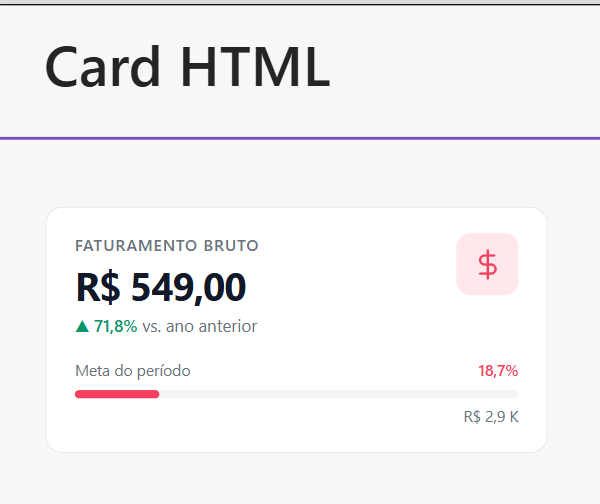

In [ ]:
HTML card-icone-canto =
//======================================================
//==================== VALORES ========================
VAR Fat    = [faturamento_bruto]
VAR Meta   = [faturamento_bruto_meta]
VAR YoY    = [faturamento_bruto YoY %]
VAR Ating  = [%atingimento_meta]
//======================================================



-- ╔══════════════════════════════════════════════════════════════════╗
-- ║                  🎨 PAINEL DE CONTROLE VISUAL                   ║
-- ║   Ajuste tudo aqui sem precisar mexer no HTML lá embaixo        ║
-- ╚══════════════════════════════════════════════════════════════════╝


-- ──────── 🏷️ TEXTOS ────────
VAR varTitulo      = "Faturamento Bruto"

VAR varLabelMeta   = "Meta do período"

VAR varComparativo = "vs. ano anterior"

-- ──────── 🎨 ÍCONE DA DIREITA ────────
-- Escolha o ícone alterando o path SVG abaixo.
-- Opções prontas — descomente a que quiser usar:

-- 💰 Cifrão (padrão)
VAR IconePath =
    "M12 1v22M17 5H9.5a3.5 3.5 0 000 7h5a3.5 3.5 0 010 7H6"

-- Tamanho da caixa do ícone (largura e altura em px)

VAR TamanhoCaixaIcone  = "44px"
-- Raio da caixa do ícone

VAR RaioCaixaIcone     = "10px"
-- Tamanho do stroke do ícone SVG

VAR StrokeIcone        = "1.8"

-- ──────── 🎨 CORES ────────
VAR CorFundo           = "#FFFFFF"

VAR CorBorda           = "#E5E7EB"

VAR CorTitulo          = "#6B7280"

VAR CorValor           = "#111827"

VAR CorBarraFundo      = "#F3F4F6"

VAR CorPosi            = "#059669"

VAR CorNega            = "#F43F5E"

VAR CorBarra100        = "#059669"   -- cor quando meta atingida

VAR CorBarraAbaixo     = "#F43F5E"   -- cor quando abaixo da meta

-- Cores da caixa do ícone (fundo e ícone em si)
-- Quando meta atingida:

VAR CorFundoIconePosi  = "#ECFDF5"

VAR CorIconePosi       = "#059669"
-- Quando abaixo da meta:

VAR CorFundoIconeNega  = "#FFE7EB"

VAR CorIconeNega       = "#F43F5E"

-- ──────── 📐 LAYOUT ────────
VAR RaioBorda          = "12px"

VAR Padding            = "18px 20px"

-- ──────── 📏 TIPOGRAFIA ────────
VAR FonteGlobal        = "'Segoe UI', system-ui, sans-serif"

VAR TamanhoTitulo      = "11px"

VAR TamanhoValor       = "28px"

VAR TamanhoVariacao    = "12px"

VAR TamanhoMeta        = "11px"

-- ──────── 🎯 BARRA DE META ────────
-- Altura da barra em px
VAR AlturaBarraPx      = "6"
-- Arredondamento da barra em px

VAR RaioBarraPx        = "3"
-- Duração da animação da barra

VAR DuracaoAnimacao    = "1.4s"

-- ──────── 🔢 FORMATAÇÃO DE VALORES ────────
-- TRUE = K / M / B  |  FALSE = valor completo
VAR AbreviarValores    = TRUE()

VAR CasasDecimais      = "1"


-- ╔══════════════════════════════════════════════════════════════════╗
-- ║                   ⚙️ LÓGICA DE NEGÓCIO                          ║
-- ║   Normalmente não é necessário mexer abaixo desta linha         ║
-- ╚══════════════════════════════════════════════════════════════════╝

VAR Posi   = YoY >= 0

VAR MetaOk = Ating >= 1

VAR _fmt   = "#,##0." & REPT("0", VALUE(CasasDecimais))

VAR FatAbs = ABS(Fat)

VAR MetAbs = ABS(Meta)

-- Progresso da barra: mínimo 0%, máximo 100% visualmente

VAR PctBarraNum = MIN(1, MAX(0, Ating)) * 100

VAR PctBarra    = FORMAT(PctBarraNum, "0") & "%"

-- Nome único da animação para reduzir conflito caso haja mais de um card na página

VAR NomeAnimacao = "progressAnimationFaturamentoV4"

VAR FatFmt =
    IF(AbreviarValores,
        SWITCH(TRUE(),
            FatAbs >= 1000000000, "R$ " & FORMAT(Fat/1000000000, _fmt) & " B",
            FatAbs >= 1000000,    "R$ " & FORMAT(Fat/1000000,    _fmt) & " M",
            FatAbs >= 1000,       "R$ " & FORMAT(Fat/1000,       _fmt) & " K",
            "R$ " & FORMAT(Fat, "#,##0.00")),
        "R$ " & FORMAT(Fat, "#,##0.00"))

VAR MetaFmt =
    IF(AbreviarValores,
        SWITCH(TRUE(),
            MetAbs >= 1000000000, "R$ " & FORMAT(Meta/1000000000, _fmt) & " B",
            MetAbs >= 1000000,    "R$ " & FORMAT(Meta/1000000,    _fmt) & " M",
            MetAbs >= 1000,       "R$ " & FORMAT(Meta/1000,       _fmt) & " K",
            "R$ " & FORMAT(Meta, "#,##0.00")),
        "R$ " & FORMAT(Meta, "#,##0.00"))

VAR YoYFmt   = FORMAT(ABS(YoY), "0.0%")

VAR AtingFmt = FORMAT(Ating,   "0.0%")

VAR CorStatus    = IF(Posi,   CorPosi,         CorNega)

VAR CorBarra     = IF(MetaOk, CorBarra100,     CorBarraAbaixo)

VAR CorFundoIcon = IF(MetaOk, CorFundoIconePosi, CorFundoIconeNega)

VAR CorIcon      = IF(MetaOk, CorIconePosi,    CorIconeNega)

VAR Seta         = IF(Posi,   "▲", "▼")

VAR Icone =
    "<svg width='22' height='22' viewBox='0 0 24 24' fill='none' " &
    "stroke='" & CorIcon & "' stroke-width='" & StrokeIcone & "' " &
    "stroke-linecap='round' stroke-linejoin='round'>" &
    "<path d='" & IconePath & "'/></svg>"


RETURN
"<!DOCTYPE html><html lang='pt-BR'><head><meta charset='UTF-8'>
<style>
  html,body{margin:0;padding:0;width:100%;height:100%;font-family:" & FonteGlobal & ";background:transparent;display:flex;align-items:center;justify-content:center;}

  .card{
    background:" & CorFundo & ";
    border:1px solid " & CorBorda & ";
    border-radius:" & RaioBorda & ";
    padding:" & Padding & ";
    width:100%;height:100%;
    box-sizing:border-box;
    display:flex;
    flex-direction:column;
    justify-content:space-between;
  }

  .topo{
    display:flex;
    align-items:flex-start;
    justify-content:space-between;
    gap:12px;
  }
  .topo-esq{ flex:1; min-width:0; }

  .label{
    font-size:" & TamanhoTitulo & ";
    font-weight:600;
    text-transform:uppercase;
    letter-spacing:.08em;
    color:" & CorTitulo & ";
    margin-bottom:6px;
    white-space:nowrap;
  }
  .value{
    font-size:" & TamanhoValor & ";
    font-weight:700;
    color:" & CorValor & ";
    letter-spacing:-1px;
    line-height:1;
    white-space:nowrap;
  }
  .yoy{
    font-size:" & TamanhoVariacao & ";
    font-weight:600;
    color:" & CorStatus & ";
    margin-top:6px;
  }
  .comp{
    font-size:" & TamanhoVariacao & ";
    color:" & CorTitulo & ";
    font-weight:400;
  }

  .icone-wrap{
    width:" & TamanhoCaixaIcone & ";
    height:" & TamanhoCaixaIcone & ";
    min-width:" & TamanhoCaixaIcone & ";
    background:" & CorFundoIcon & ";
    border-radius:" & RaioCaixaIcone & ";
    display:flex;
    align-items:center;
    justify-content:center;
    flex-shrink:0;
  }

  .meta-row{
    display:flex;
    justify-content:space-between;
    align-items:center;
    margin-top:14px;
  }
  .meta-label{ font-size:" & TamanhoMeta & ";color:" & CorTitulo & "; }
  .meta-pct{   font-size:" & TamanhoMeta & ";font-weight:600;color:" & CorBarra & "; }

  .bar-bg{
    background:" & CorBarraFundo & ";
    border-radius:" & RaioBarraPx & "px;
    height:" & AlturaBarraPx & "px;
    width:100%;
    margin-top:6px;
    overflow:hidden;
  }

  .bar-fill{
    height:100%;
    border-radius:" & RaioBarraPx & "px;
    background:" & CorBarra & ";
    width:" & PctBarra & ";
    animation:" & NomeAnimacao & " " & DuracaoAnimacao & " cubic-bezier(.22,.61,.36,1) both;
    will-change:width;
  }

  @keyframes " & NomeAnimacao & "{
    from{width:0%;}
    to{width:" & PctBarra & ";}
  }

  .meta-val{
    font-size:" & TamanhoMeta & ";
    color:" & CorTitulo & ";
    margin-top:4px;
    text-align:right;
  }
</style></head><body>

<div class='card'>

  <div class='topo'>
    <div class='topo-esq'>
      <div class='label'>" & varTitulo & "</div>
      <div class='value'>" & FatFmt & "</div>
      <div class='yoy'>" & Seta & " " & YoYFmt & "
        <span class='comp'>" & varComparativo & "</span>
      </div>
    </div>
    <div class='icone-wrap'>" & Icone & "</div>
  </div>

  <div>
    <div class='meta-row'>
      <span class='meta-label'>" & varLabelMeta & "</span>
      <span class='meta-pct'>" & AtingFmt & "</span>
    </div>
    <div class='bar-bg'><div class='bar-fill'></div></div>
    <div class='meta-val'>" & MetaFmt & "</div>
  </div>

</div>
</body></html>"
